In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fn="ML-Python-Lab-Data.csv"
np.random.seed(42)


### Load the data file and explore the data, showing size, data descriptions,data distributions with boxplot, pairplots

In [2]:
features=["Sex", "Length", "Diameter", "Height", "Whole weight", "Shucked weight", "Viscera weight", "Shell weight", "Rings"]
df=pd.read_csv(fn, names=features, index_col=0)
df.head()


,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.514,0.2245,0.1010,0.150,2.0
1,M,0.350,0.265,0.090,NaN,0.0995,0.0485,0.070,0.0
2,F,0.530,0.420,0.135,NaN,0.2565,0.1415,0.210,1.0
3,M,0.440,0.365,0.125,0.516,0.2155,0.1140,0.155,1.0
4,I,0.330,0.255,0.080,0.205,0.0895,0.0395,0.055,0.0


In [3]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,3997.000000,3976.000000,3987.000000,3990.000000,3983.000000,4002.000000,3990.000000,4177.000000
mean,0.525330,0.408448,0.139669,0.830577,0.360681,0.180995,0.239796,0.861623
std,0.119569,0.098728,0.041988,0.490629,0.221100,0.109425,0.139765,0.762510
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,0.000000
25%,0.450000,0.350000,0.115000,0.444500,0.188000,0.094000,0.130000,0.000000
50%,0.545000,0.425000,0.140000,0.802250,0.339000,0.171500,0.235000,1.000000
75%,0.615000,0.480000,0.165000,1.154375,0.503250,0.253500,0.330000,1.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,3.000000


In [4]:
print(f"colonne: {df.shape[1]}, righe: {df.shape[0]}")

colonne: 9, righe: 4177


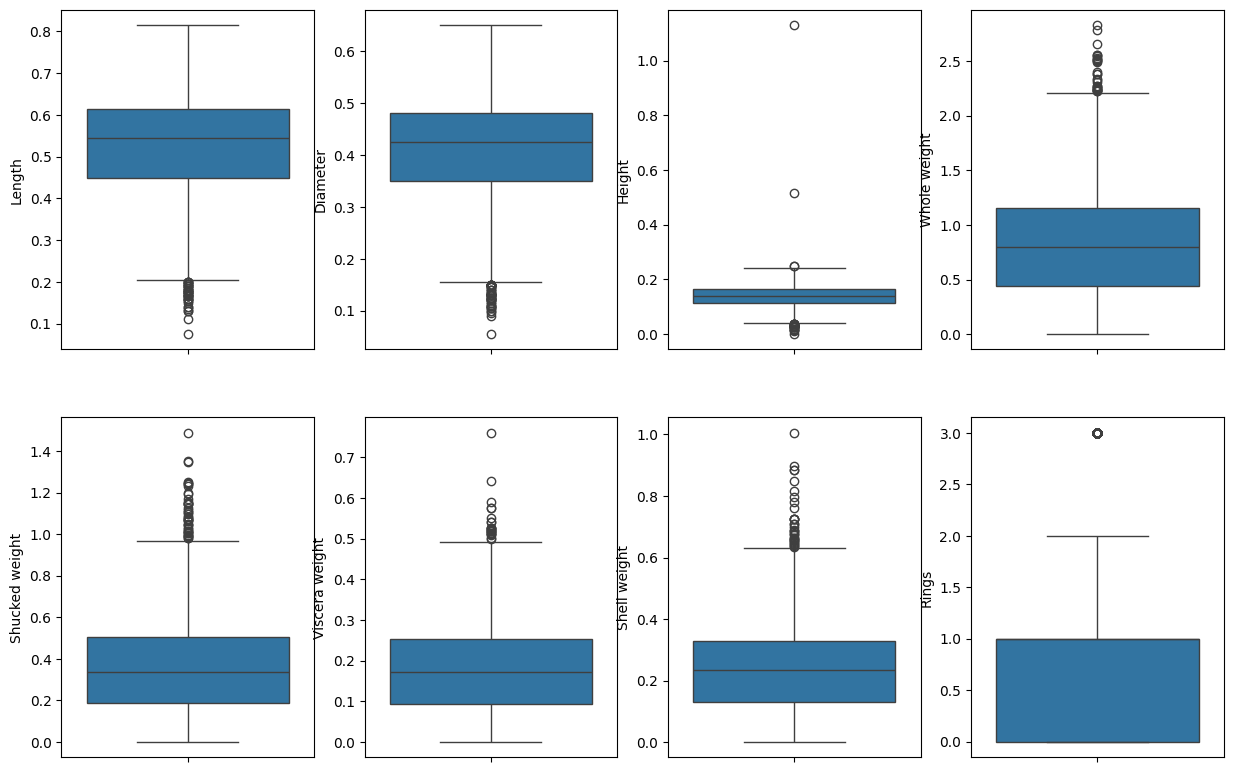

In [5]:
df_for_boxplot = df.drop(['Sex'], axis=1)
plt.figure(figsize=(15,15))
pos = 1
for i in df_for_boxplot.columns:
    plt.subplot(3, 4, pos)
    sns.boxplot(data=df[i])
    pos += 1

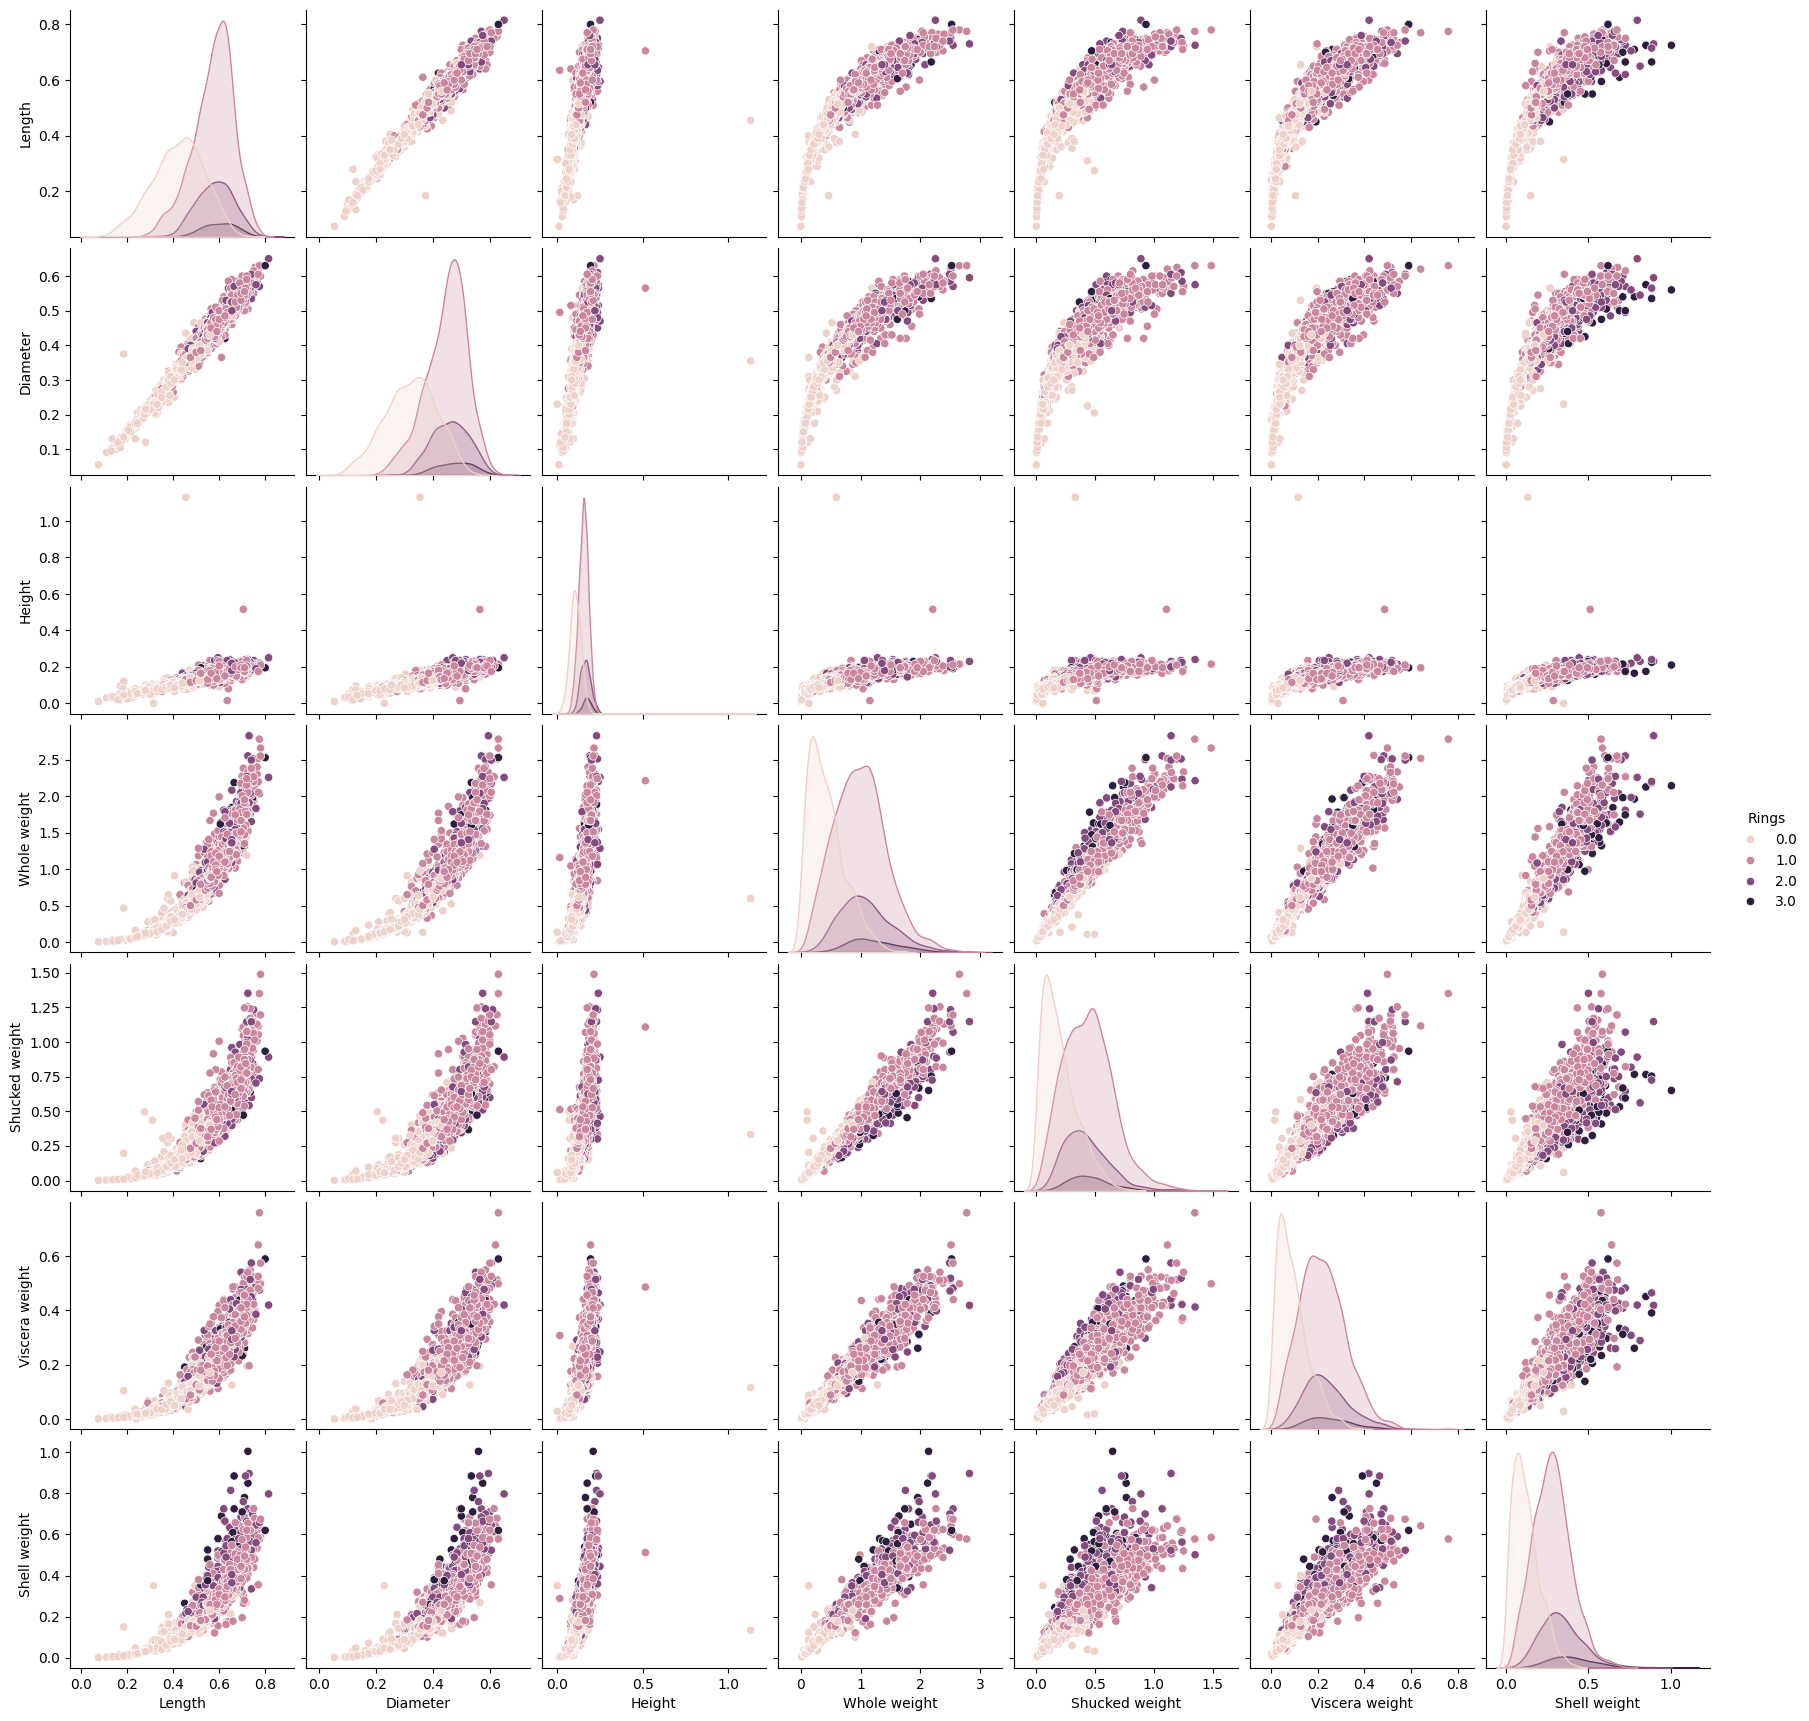

In [6]:
sns.pairplot(df, hue = "Rings")

## Comment the exploration of step 1 pointing out if there are imbalanced distributions, outliers, missing values

No imbalanced distribution, outliers on Height feature, some missing values for Whole Wheight feature

### Drop the columns that are not relevant for the classification operation, if any, and explain why you do that. Deal with missing values, if any

Dropping SEX column cause it's useless for classification in this scenario

(3052, 8)


<Axes: >

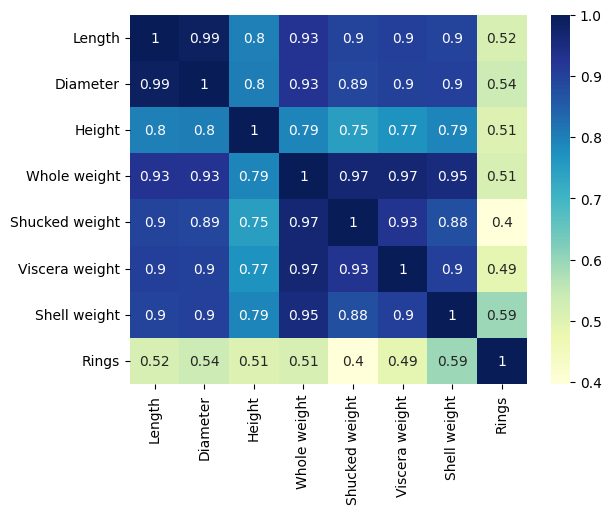

In [10]:
df_for_classif=df.drop(['Sex'], axis=1)
df_for_classif=df_for_classif.dropna()
print(df_for_classif.shape)

sns.heatmap(df_for_classif.corr(), cmap="YlGnBu",annot=True)

### find the best classification scheme considering two classification methods, find the best hyperparameters using cross validation; the optimization must be focused on the f1_macro measure

In [14]:
from sklearn.model_selection import train_test_split
target = "Rings"
X=df_for_classif.drop(target,axis=1)
y=df_for_classif[target]
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,train_size=2/3, random_state=42)
print(f"items in train: {Xtrain.shape[0]}")
print(f"items in test: {Xtest.shape[0]}")
Xtrain

items in train: 2034
items in test: 1018


,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
2549,0.280,0.210,0.055,0.1060,0.0415,0.0265,0.031
296,0.275,0.205,0.075,0.1105,0.0450,0.0285,0.035
1859,0.515,0.415,0.135,0.7125,0.2850,0.1520,0.245
367,0.580,0.455,0.120,1.0735,0.4790,0.2735,0.265
2976,0.430,0.345,0.115,0.4295,0.2120,0.1080,0.109
...,...,...,...,...,...,...,...
2236,0.560,0.435,0.185,1.1060,0.4220,0.2435,0.330
1502,0.630,0.480,0.150,1.2710,0.6605,0.2425,0.310
1548,0.385,0.290,0.090,0.2365,0.1000,0.0505,0.076
1779,0.500,0.370,0.150,1.0615,0.4940,0.2230,0.296


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn=KNeighborsClassifier()

knn_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

knn_params = [{'n_neighbors': knn_neighbors}]
knn_gs = GridSearchCV(  knn,
                        knn_params,
                        cv=5,
                        scoring='f1_macro',        
                        return_train_score = False,
                        n_jobs = 2,
                )

# Fit it to the training data
knn_gs.fit(Xtrain, ytrain)

# Print the best parameters found
print(f"The best parameter found for the Nearest Neighbors was {knn_gs.best_params_}")


The best parameter found for the Nearest Neighbors was {'n_neighbors': 1}


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Instantiate the DecisionTree Classifier
dt = DecisionTreeClassifier(random_state = 42)

# Fit it to the training data
dt.fit(Xtrain, ytrain)

# Create the range of parameters to try during cross-validation
dt_depths = range(1, dt.get_depth() + 1)

# We will use GridSearchCV to perform cross-validation
# we need to create the parameter list in a specific way
# for it to work
dt_params = [{'max_depth': list(dt_depths), 'random_state': [42]}]

# Scoring
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
scoring = 'f1_macro'

# Instantiate GridSearchCV
dt_gs = GridSearchCV(   dt,
                        dt_params,
                        cv=5,
                        scoring=scoring,
                        return_train_score = False,
                        n_jobs = 2,
                    )

# Fit it to the training data
dt_gs.fit(Xtrain, ytrain)

# Print the best parameters found
print(f"The best parameter found for the Decision Tree was {dt_gs.best_params_}")

The best parameter found for the Decision Tree was {'max_depth': 8, 'random_state': 42}


In [23]:
dt = DecisionTreeClassifier(max_depth = dt_gs.best_params_["max_depth"], random_state = 42)
dt.fit(Xtrain, ytrain)

# Predict the test set in order to be able to compute the metrics later on
dt_ypred = dt.predict(Xtest)

### Show the performance measures and the confusion matrices for the best hyperparameters of each model

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# Model labels to facilitate iterations
model_lbls = ['dt','knn']

# set the models to be fitted specifying name, estimator and parameter structure
models = {
            'dt':   {
                        'name': 'Decision Tree ',
                        'estimator': DecisionTreeClassifier()
                    },
            'knn':
                    {   'name': 'K Nearest Neighbor ',
                        'estimator': KNeighborsClassifier()
                    }
        }

In [29]:
estimator_dt = DecisionTreeClassifier(max_depth = dt_gs.best_params_["max_depth"], random_state = 42)

estimator_knn = KNeighborsClassifier(n_neighbors = knn_gs.best_params_["n_neighbors"])

estimator_dt.fit(Xtrain, ytrain)
estimator_knn.fit(Xtrain, ytrain)


    # 6. For each classification method compute the accuracy and the confusion matrix on the test set

    # Predict the test set in order to be able to compute the metrics later on
model_ypred_dt = estimator_dt.predict(Xtest)
model_ypred_knn = estimator_knn.predict(Xtest)
    # Classification Report
print("Classification report knn: ")
print(classification_report(ytest, model_ypred_knn))

print("Classification report dt: ")
print(classification_report(ytest, model_ypred_dt))



Classification report knn: 
              precision    recall  f1-score   support

         0.0       0.63      0.68      0.65       302
         1.0       0.60      0.59      0.60       487
         2.0       0.42      0.41      0.41       191
         3.0       0.14      0.08      0.10        38

    accuracy                           0.57      1018
   macro avg       0.45      0.44      0.44      1018
weighted avg       0.56      0.57      0.56      1018

Classification report dt: 
              precision    recall  f1-score   support

         0.0       0.73      0.68      0.70       302
         1.0       0.63      0.75      0.69       487
         2.0       0.47      0.38      0.42       191
         3.0       0.33      0.05      0.09        38

    accuracy                           0.63      1018
   macro avg       0.54      0.47      0.47      1018
weighted avg       0.62      0.63      0.62      1018



Text(0.5, 1.0, 'The confusion matrix for dt')

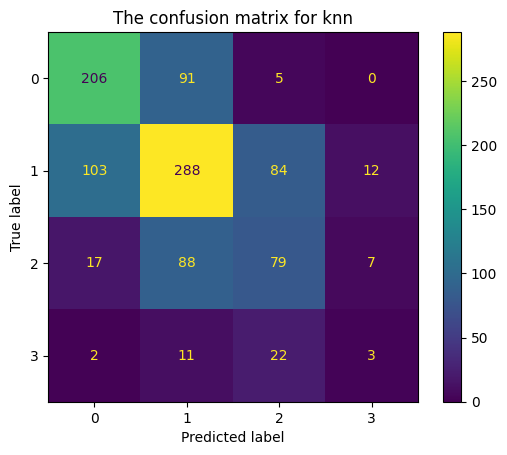

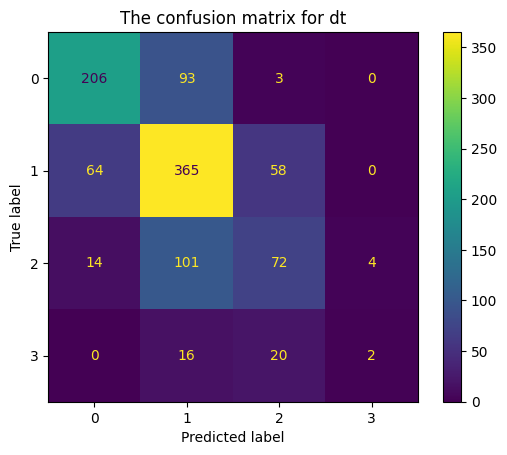

In [30]:
models['dt']['f1_score'] = accuracy_score(ytest, model_ypred_dt) * 100
        # Accuracy of the KNN Classifier
models['knn']['f1_score'] = accuracy_score(ytest, model_ypred_knn) * 100

    # Confusion matrix
cm_model_knn = confusion_matrix(ytest,model_ypred_knn)
cm_model_dt = confusion_matrix(ytest,model_ypred_dt)
CMD_knn = ConfusionMatrixDisplay(cm_model_knn)
CMD_knn.plot()
CMD_knn.ax_.set_title(f"The confusion matrix for knn")

CMD_dt = ConfusionMatrixDisplay(cm_model_dt)
CMD_dt.plot()
CMD_dt.ax_.set_title(f"The confusion matrix for dt")
